# Calculating Trajectories

🎯 **Goal**: Estimate each contestant’s probability of winning a series using only information available at a given episode, and track how this evolves over time.

In Notebook 4, I simulated full series using complete historical data. However, in a live setting, future performance is unknown.

This notebook adapts the simulation approach to use partial series data, enabling forward-looking win probabilities that update as the series progresses.

**Approach**:
- Select a snapshot at episode *t* for a given series  
- Use `mean_score_so_far` and `std_score_so_far` to estimate current performance  
- Simulate **remaining episodes only**  
- Combine simulated future scores with current cumulative score  
- Repeat simulation many times to estimate win probabilities  
- Track how these probabilities evolve across episodes  
- Compare trajectories to actual outcomes and earlier model predictions 

### Executive Summary

- Simulated win probabilities at each episode using partial series data  
- Across sampled series, the eventual winner has **low probability at Episode 1 (0–17%)**, indicating weak early signal  
- The point at which the winner becomes more likely than not (>50%) varies significantly:
  - Early (Episode 2) in some series  
  - Mid-series (Episode 4) in others  
  - Late (Episode 7) in more competitive cases  
- By the penultimate episode, the winner is consistently **strongly favoured (60–80%)**, even when earlier stages were uncertain  

**Key insight:**  
> While early performance contains some signal, the timing of predictability varies by series. Some competitions are effectively decided early, while others remain open until the final episodes.

**Comparison to model:**  
> The predictive model often identifies the winner earlier, but the simulation shows that meaningful uncertainty persists for much of the series.

### Imports

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

PROCESSED_PATH = DATA_DIR / "processed"

### Load the data

In [12]:
snapshot_df = pd.read_csv(PROCESSED_PATH / "snapshot_df.csv")

snapshot_df.columns.to_list()

['episode',
 'episode_label',
 'contestant',
 'episode_score',
 'series_id',
 'episode_in_series',
 'cumulative_score',
 'mean_score_so_far',
 'std_score_so_far',
 'recent_avg_score',
 'momentum',
 'episodes_played',
 'final_score',
 'total_episodes',
 'final_rank',
 'won_series',
 'remaining_episodes',
 'current_rank']

## Creating a simple simulation

Note: We're assuming that future performance ≈ behaviour observed so far

So below, we are pausing Series 5 at Episode 3 and asking:

*"Given what we’ve seen so far, how does the rest of the series likely play out?"*

### Simulate one series from a snapshot

In [13]:
# ----- Simulating a series from an episode snapshot -----

# Select an episode (as an example: series 5, episode 3)
series_to_simulate = 5
episode_t = 3

snapshot_t = snapshot_df[
    (snapshot_df["series_id"] == series_to_simulate)
    &
    (snapshot_df["episode_in_series"] == episode_t)
].copy()

# What we know about each contestant at this point in the series:
snapshot_t

,episode,episode_label,contestant,episode_score,series_id,episode_in_series,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,momentum,episodes_played,final_score,total_episodes,final_rank,won_series,remaining_episodes,current_rank
130,27,Phoenix.,Aisling Bea,13,5,3,43,14.333333,2.309401,15.0,0.666667,3,126,8,4.0,0,5,5.0
131,27,Phoenix.,Bob Mortimer,17,5,3,51,17.000000,1.000000,16.5,-0.500000,3,138,8,1.0,1,5,1.0
132,27,Phoenix.,Mark Watson,15,5,3,51,17.000000,2.000000,17.0,0.000000,3,130,8,2.0,0,5,1.0
133,27,Phoenix.,Nish Kumar,12,5,3,44,14.666667,3.785939,15.5,0.833333,3,107,8,5.0,0,5,4.0
134,27,Phoenix.,Sally Phillips,16,5,3,50,16.666667,3.055050,18.0,1.333333,3,130,8,2.0,0,5,3.0


In [16]:
# Build simulation inputs
simulation_inputs = snapshot_t[[
    "contestant",
    "cumulative_score",
    "mean_score_so_far",
    "std_score_so_far",
    "remaining_episodes"
]].copy()

# Handle standard deviation of 0 (i.e. no variance in scores so far) by adding a small constant
global_std = snapshot_df["std_score_so_far"].mean()

simulation_inputs["std_score_so_far"] = simulation_inputs["std_score_so_far"].fillna(global_std)

simulation_inputs.loc[simulation_inputs["std_score_so_far"] == 0, "std_score_so_far"] = global_std

In [ ]:
# Simulate the rest of series 5 one time

def simulate_from_snapshot(simulation_inputs, random_state=None):
    """
    Simulate the rest of a series from a given snapshot of contestant performance up to a certain episode.

    Parameters:
    - simulation_inputs: DataFrame containing contestant performance metrics at the snapshot episode.
    - random_state: Optional random seed for reproducibility.

    Returns:
    - DataFrame with simulated final scores for each contestant at the end of the series.
    """

    # Generate random numbers for the simulation
    rng = np.random.default_rng(random_state)

    results = []

    # Iterate over each contestant in the snapshot
    for _, row in simulation_inputs.iterrows():

        # Extract contestant info and performance metrics
        contestant = row["contestant"]
        current_score = row["cumulative_score"]
        mean_score = row["mean_score_so_far"]
        std_score = row["std_score_so_far"]
        remaining_eps = int(row["remaining_episodes"])

        # Simulate scores for the remaining episodes
        simulated_future_scores = rng.normal(
            loc=mean_score,         # average performance so far
            scale=std_score,        # variability in performance so far
            size=remaining_eps      # number of remaining episodes to simulate
        )

        # Keep values realistic (capped at 35)
        simulated_future_scores = np.clip(
            simulated_future_scores, 0, 35  # based on historical max 30
            )

        # Total future score
        total_future_score = simulated_future_scores.sum()

        # Final total score for the contestant
        simulated_final_score = current_score + total_future_score

        results.append({
            "contestant": contestant,
            "final_score": simulated_final_score
        })

    # Return results as DataFrame
    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "final_score", ascending=False
    ).reset_index(drop=True)

    return results_df

In [18]:
sim_one = simulate_from_snapshot(simulation_inputs, random_state=42)

sim_one

,contestant,final_score
0,Mark Watson,142.635942
1,Bob Mortimer,133.639573
2,Sally Phillips,132.642562
3,Nish Kumar,114.982644
4,Aisling Bea,112.368151


### Simulate series outcome multiple times

In [ ]:
# Simulate the rest of Series 5 multiple times to get a distribution of outcomes

def simulate_many_from_snapshot(simulation_inputs, n_simulations=1000):
    """
    Simulate the rest of a series multiple times from a given snapshot of contestant performance.

    Parameters:
    - simulation_inputs: DataFrame containing contestant performance metrics at the snapshot episode.
    - n_simulations: Number of simulations to run.

    Returns:
    - DataFrame with simulated final scores for each contestant across all simulations.
    """
    all_results = []

    for sim_id in range(n_simulations):

        sim_result = simulate_from_snapshot(
            simulation_inputs,
            random_state=sim_id        # Use sim_id for reproducibility
        )

        # Add simulation ID to the results
        sim_result["simulation_id"] = sim_id

        # Add rank based on final score
        sim_result["rank"] = sim_result["final_score"].rank(
            method="min", ascending=False
        ).astype(int)

        all_results.append(sim_result)

    # Combine all simulation results into a single DataFrame
    all_results_df = pd.concat(all_results, ignore_index=True)

    return all_results_df


In [20]:
# Simulate win probabilities from snapshot based on 1000 simulations
simulations_df = simulate_many_from_snapshot(simulation_inputs)

win_probabilities = (
    simulations_df[simulations_df["rank"] == 1] # Only sims where contestant wins
    .groupby("contestant")
    .size()
    .reset_index(name="wins")
)

n_simulations = simulations_df["simulation_id"].nunique()
win_probabilities["win_probability"] = win_probabilities["wins"] / n_simulations

# Include all contestants (even those who never won!)
all_contestants = pd.DataFrame({
    "contestant": simulation_inputs["contestant"]
})

win_probabilities = all_contestants.merge(
    win_probabilities,
    on="contestant",
    how="left"
)

# Fill NaN win probabilities with 0, sort by win probability
win_probabilities = win_probabilities.fillna(0).sort_values(
    "win_probability", ascending=False
    )

win_probabilities

,contestant,wins,win_probability
2,Mark Watson,395.0,0.395
1,Bob Mortimer,324.0,0.324
4,Sally Phillips,276.0,0.276
3,Nish Kumar,5.0,0.005
0,Aisling Bea,0.0,0.000


### Tracking probabilities over time

In [ ]:
def get_win_proba_at_episode(snapshot_df, series_id, episode_t, n_simulations=1000):
    """
    Get win probabilities for each contestant at a specific episode in a series based on simulations.

    Parameters:
    - snapshot_df: DataFrame containing snapshots of contestant performance
    - series_id: ID of the series to analyze
    - episode_t: Episode number to analyze (1-based index)
    - n_simulations: Number of simulations to run for estimating win probabilities

    Returns:
    - DataFrame with contestants and their estimated win probabilities at the specified episode.
    """
    # Filter snapshot for the specified series and episode
    snapshot_t = snapshot_df[
        (snapshot_df["series_id"] == series_id)
        &
        (snapshot_df["episode_in_series"] == episode_t)
    ].copy()

    # Build simulation inputs
    simulation_inputs = snapshot_t[[
        "contestant",
        "cumulative_score",
        "mean_score_so_far",
        "std_score_so_far",
        "remaining_episodes"
    ]].copy()

    # Handle standard deviation of 0 by filling with global mean
    global_std = snapshot_df["std_score_so_far"].mean()
    simulation_inputs["std_score_so_far"] = simulation_inputs["std_score_so_far"].fillna(global_std)
    simulation_inputs.loc[simulation_inputs["std_score_so_far"] == 0, "std_score_so_far"] = global_std

    # Run simulations to get win probabilities
    simulations_df = simulate_many_from_snapshot(
        simulation_inputs,
        n_simulations=n_simulations
    )

    win_probabilities = (
        simulations_df[simulations_df["rank"] == 1] # Only sims where contestant wins
        .groupby("contestant")
        .size()
        .reset_index(name="wins")
    )

    win_probabilities["win_probability"] = win_probabilities["wins"] / n_simulations

    # Include all contestants (even those who never won!)
    all_contestants = pd.DataFrame({
        "contestant": simulation_inputs["contestant"]
    })

    win_probabilities = all_contestants.merge(
        win_probabilities,
        on="contestant",
        how="left"
    ).fillna(0).sort_values("win_probability", ascending=False)

    # Add episode column for clarity
    win_probabilities["episode"] = episode_t

    return win_probabilities

In [ ]:
# Loop over episodes in series 5 and get win probabilities at each episode
series_id = 5

all_results = []

# Get total episodes in the series
total_episodes = snapshot_df[
    snapshot_df["series_id"] == series_id
]["episode_in_series"].max()

for episode_t in range(1, total_episodes + 1):

    win_probabilities = get_win_proba_at_episode(
        snapshot_df,
        series_id=series_id,
        episode_t=episode_t,
        n_simulations=1000
    )

    all_results.append(win_probabilities)

win_probabilities_over_time = pd.concat(all_results, ignore_index=True)

In [24]:
win_probabilities_over_time.head(10)

,contestant,wins,win_probability,episode
0,Bob Mortimer,749.0,0.749,1
1,Mark Watson,251.0,0.251,1
2,Aisling Bea,0.0,0.000,1
3,Nish Kumar,0.0,0.000,1
4,Sally Phillips,0.0,0.000,1
5,Mark Watson,703.0,0.703,2
6,Sally Phillips,207.0,0.207,2
7,Nish Kumar,58.0,0.058,2
8,Bob Mortimer,32.0,0.032,2
9,Aisling Bea,0.0,0.000,2


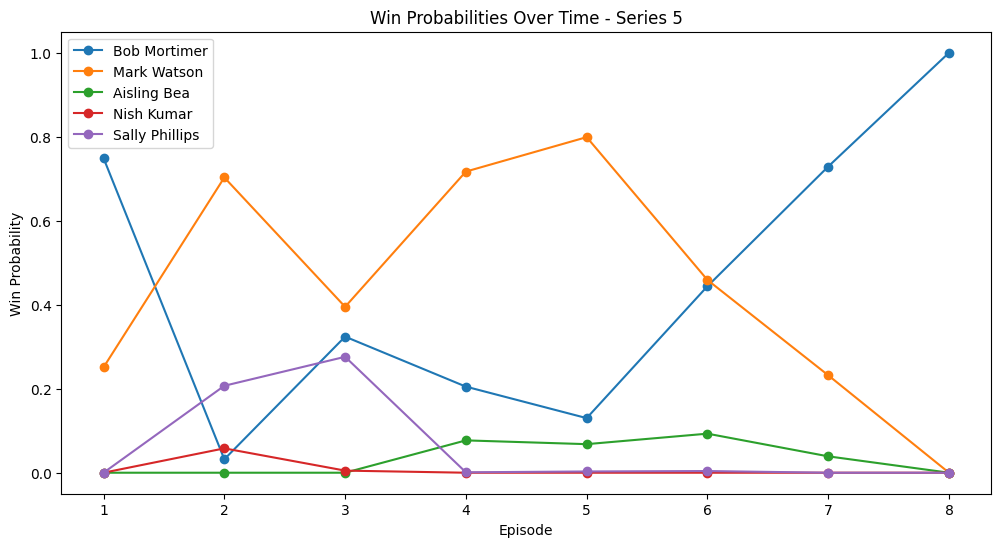

In [26]:
plt.figure(figsize=(12, 6))

for contestant in win_probabilities_over_time["contestant"].unique():

    contestant_data = win_probabilities_over_time[
        win_probabilities_over_time["contestant"] == contestant
    ]

    plt.plot(
        contestant_data["episode"],
        contestant_data["win_probability"],
        marker="o",
        label=contestant
    )

plt.xlabel("Episode")
plt.ylabel("Win Probability")
plt.title("Win Probabilities Over Time - Series 5")
plt.legend()
plt.show()

#### 👆 How Series 5 Unfolds

*The series winner become predictable **over time** - but not immediately.*

Win probabilities are highly volatile in the early episodes, with different contestants briefly emerging as favourites. Mark Watson appears strongest through the middle of the series, reaching an ~80% win probability by episode 5.

However, this shifts dramatically in later episodes, with Bob Mortimer overtaking and converging to a 100% win probability by the final episode. This highlights how early leads can be misleading, and how cumulative performance ultimately determines the outcome.

Overall, the chart shows that while the series becomes increasingly predictable over time, the eventual winner is not clearly established until the later stages.

----

#### 💡 Connecting prediction and simulation

The evolution of win probabilities provides an interesting contrast to the predictive model developed earlier.

In Notebook 3, the Ridge model was able to identify the eventual winner relatively early in the series, suggesting that early performance contains meaningful signal. However, the simulation shows that this signal does not translate into certainty - probabilities remain distributed across multiple contestants through the early and mid stages.

In this series, Mark Watson appears as the most likely winner through the middle episodes, despite Bob Mortimer ultimately winning. This highlights the difference between identifying a likely outcome and accounting for uncertainty: early leaders may be favoured by the model, but the range of possible outcomes remains wide until later in the series.

Taken together, these results suggest that while the eventual winner is often *implied* early on, the competition remains genuinely open for much of the series when variability in performance is taken into account.

👉 **Early performance signals who might win, but only simulation reveals how uncertain that outcome remains.**

## Validating simulation across multiple series

*Does early predictability vs late uncertainty depend on the series?*

In [27]:
# Select a few series at random
np.random.seed(42)

series_sample = np.random.choice(
    snapshot_df["series_id"].dropna().unique(), 3, replace=False
)

series_sample

array([ 1, 18, 16])

In [28]:
# Simulate predictions for the selected series sample
# Plot win probabilities over time for each
all_series_results = []

# Loop over selected series
for series_id in series_sample:

    total_episodes = snapshot_df[
        snapshot_df["series_id"] == series_id
    ]["episode_in_series"].max()

    all_results = []

    # Loop over episodes in the series and get win probabilities at each episode
    for episode_t in range(1, total_episodes + 1):

        win_probs_t = get_win_proba_at_episode(
            snapshot_df,
            series_id=series_id,
            episode_t=episode_t,
            n_simulations=1000
        )

        win_probs_t["series_id"] = series_id

        all_results.append(win_probs_t)

    series_df = pd.concat(all_results, ignore_index=True)

    all_series_results.append(series_df)

multi_series_df = pd.concat(all_series_results, ignore_index=True)

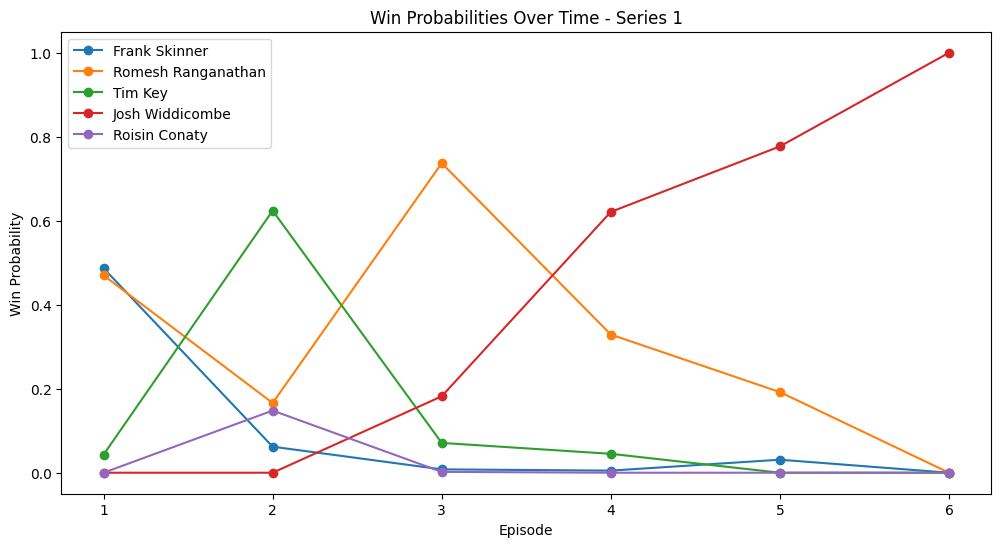

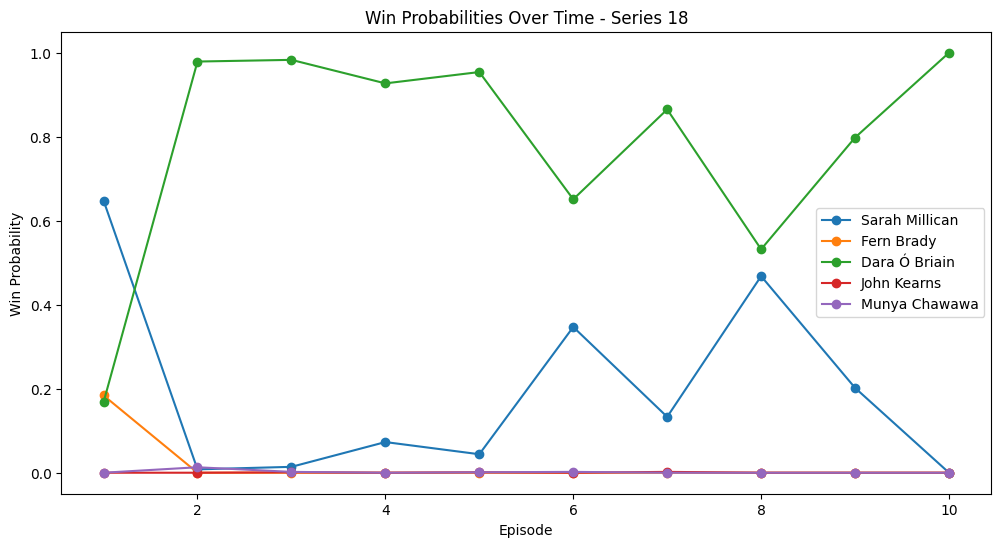

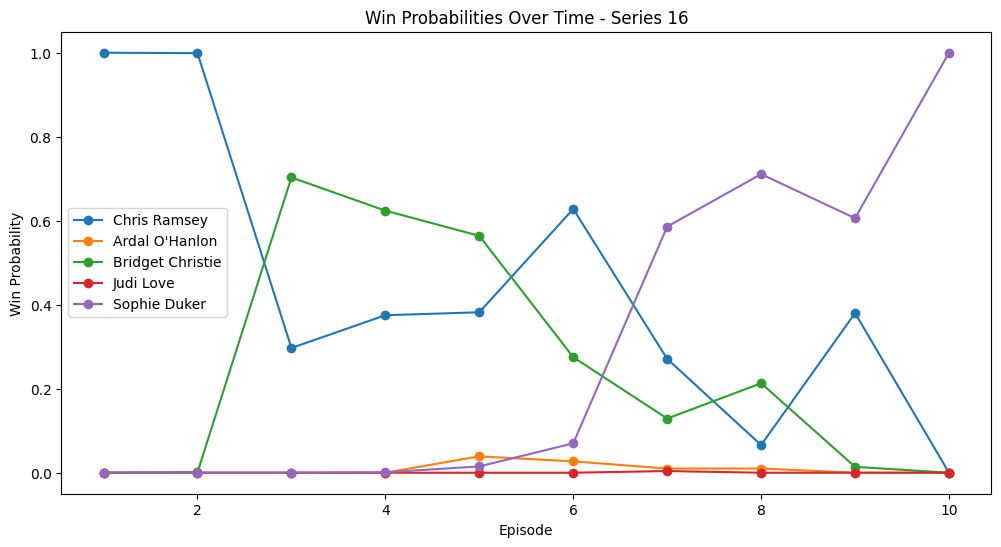

In [30]:
# Plot win probabilities over time for each series in the sample

for series_id in series_sample:

    # Filter data for the current series
    series_data = multi_series_df[multi_series_df["series_id"] == series_id]

    plt.figure(figsize=(12, 6))

    for contestant in series_data["contestant"].unique():

        contestant_data = series_data[
            series_data["contestant"] == contestant
        ]

        plt.plot(
            contestant_data["episode"],
            contestant_data["win_probability"],
            marker="o",
            label=contestant
        )

    plt.xlabel("Episode")
    plt.ylabel("Win Probability")
    plt.title(f"Win Probabilities Over Time - Series {series_id}")
    plt.legend()
    plt.show()

### 🔍 Do win probability patterns hold across series?

*Win probability trajectories vary significantly across different series.*

In some cases, such as Series 18, the eventual winner emerges almost immediately and maintains a dominant position throughout. In others, like Series 1, leadership shifts during the middle of the series before stabilising later on. Series 16 shows an even more extreme pattern, where early leaders are overtaken and the eventual winner only becomes clear in the final episodes.

These differences suggest that while early performance can contain predictive signal, the degree of uncertainty depends heavily on the dynamics of the series. Some competitions are effectively decided early, while others remain open until the final stages.

This reinforces that Taskmaster outcomes are shaped not only by performance, but also by variability and the evolving competitive context within each series.

👉 This variability also highlights the value of a probabilistic approach - **a single prediction cannot capture the range of possible outcomes across different series.**

## Comparing simulations with actual outcomes

Track the actual winner’s simulated win probability over time, then identify when they first became more likely than not to win

In [33]:
summary_rows = []

for series_id in series_sample:

    # Get actual winner for the series
    actual_winner = snapshot_df[
        (snapshot_df["series_id"] == series_id)
        &
        (snapshot_df["won_series"] == True)
    ]["contestant"].iloc[0]

    # Get winner's simulated trajectory
    winner_trajectory = multi_series_df[
        (multi_series_df["series_id"] == series_id)
        &
        (multi_series_df["contestant"] == actual_winner)
    ].sort_values("episode")

    # Probability of winning at the first episode
    ep1_win_prob = winner_trajectory.iloc[0]["win_probability"]

    # Proabaility of winning at the final episode
    final_win_prob = winner_trajectory.iloc[-1]["win_probability"]

    # Probability of winning at the penultimate episode (if we have more than one episode)
    if len(winner_trajectory) > 1:
        penultimate_win_prob = winner_trajectory.iloc[-2]["win_probability"]
    else:
        penultimate_win_prob = None

    # Identify episode where winner's win probability first exceeds 50%
    over_50pc = winner_trajectory[winner_trajectory["win_probability"] >= 0.5]

    if not over_50pc.empty:
        first_ep_over_50pc = over_50pc.iloc[0]["episode"]
    else:
        first_ep_over_50pc = None

    summary_rows.append({
        "series_id": series_id,
        "actual_winner": actual_winner,
        "winner_prob_at_ep1": ep1_win_prob,
        "winner_prob_at_penultimate": penultimate_win_prob,
        "first_episode_over_50pc": first_ep_over_50pc,
        "final_winner_prob": final_win_prob
    })

winner_timing_summary = pd.DataFrame(summary_rows)

winner_timing_summary

,series_id,actual_winner,winner_prob_at_ep1,winner_prob_at_penultimate,first_episode_over_50pc,final_winner_prob
0,1,Josh Widdicombe,0.000,0.777,4,1.0
1,18,Dara Ó Briain,0.168,0.798,2,1.0
2,16,Sophie Duker,0.000,0.606,7,1.0


### 🎯 When does the winner become clear?

Comparing simulated win probabilities with actual outcomes shows that the timing of predictability varies significantly across series.

In all three cases, the eventual winner has a low probability in the first episode, suggesting that early performance alone is not sufficient to identify the winner. However, the point at which the winner becomes more likely than not differs markedly.

- In Series 1, Josh Widdicombe only becomes the most likely winner around Episode 4.
- In Series 16, Sophie Duker does not emerge as the favourite until Episode 7, reflecting a much more open competition.
- In Series 18, Dara Ó Briain becomes the clear favourite by Episode 2, indicating an early lock-in.

Despite these differences, by the penultimate episode the winner is strongly favoured in all cases, suggesting that uncertainty reduces as the series progresses, even if the timing of that shift varies.

👉 Overall, this highlights that **while early performance contains some signal, the point at which the outcome becomes meaningfully predictable depends heavily on the dynamics of the individual series**.

*Some series are decided early. Others only reveal their winner at the very end.*

----

### 🙋‍♀️ Why do simulation and prediction differ?

The predictive model and simulation approach produce different perspectives on the same problem.

- **Prediction**: The Ridge model leverages patterns learned across historical data and incorporates multiple features such as rank, momentum, and consistency. As a result, it is often able to identify the eventual winner relatively early.

- **Simulation**: The simulation is based only on observed performance within the current series, using mean and variability to generate possible future outcomes. It assumes that future performance will resemble behaviour observed so far, and does not incorporate broader historical patterns.

This leads to an important distinction: the model provides a strong point prediction, while the simulation captures the range of possible outcomes. As a result, the model may identify the likely winner earlier, but the simulation shows that the outcome often remains uncertain for much of the series.

Together, these approaches provide complementary insights - one highlighting predictive signal, and the other quantifying uncertainty.

| Aspect | Predictive Model (Ridge) | Simulation (Monte Carlo) |
|-------|--------------------------|---------------------------|
| **Goal** | Predict the most likely final outcome | Estimate range of possible outcomes |
| **Approach** | Learns patterns from historical data across all series | Samples future outcomes based on current performance |
| **Inputs** | Multiple features (score, rank, momentum, consistency, etc.) | Mean and variability of scores so far |
| **Output** | Single predicted winner | Probability of each contestant winning |
| **Treatment of uncertainty** | Collapses uncertainty into one prediction | Explicitly models uncertainty via many simulations |
| **Use of history** | Leverages patterns across all past series | Uses only current series behaviour |
| **Strengths** | Identifies likely winner early | Reflects how uncertain the outcome remains |
| **Limitations** | Can appear overconfident | Assumes future ≈ past behaviour |
| **Observed behaviour** | Often predicts winner early | Shows shifting probabilities and late changes in leadership |

## 💡 Conclusion

This notebook extends the simulation approach to a live setting by using only information available at each episode.

By simulating the remaining episodes and tracking win probabilities over time, I move from static prediction to a dynamic view of the competition. This reveals not just who is likely to win, but how certainty evolves as the series progresses.

Across multiple series, the timing of predictability varies significantly. Some series show early lock-in, while others remain uncertain until the final episodes. This highlights the importance of both performance level and variability in shaping outcomes.

Comparing these results to the earlier predictive model shows that while strong signals can emerge early, the outcome often remains genuinely uncertain for much of the series when variability is taken into account.

This trajectory-based view provides a more nuanced understanding of competition dynamics and sets the stage for applying this framework in a real-world, live context.


### 🚀 Next steps

The next step is to apply this framework to a new Taskmaster series as it airs.

This involves:
- Capturing episode-level results as new data becomes available  
- Updating performance metrics after each episode  
- Re-running the simulation to produce updated win probabilities  

This would enable a simple live system that tracks how likely each contestant is to win as the series unfolds.